In [1]:
import cv2
from matplotlib import pyplot as plt
from pathlib import Path

import src.ModelTrain as ModelTrain

In [2]:
F1_FIG_NAME = 'f1_score_evolution.png'
LOSS_FIG_NAME = 'loss_evolution.png'
CONF_MATRIX_NAME = 'confusion_matrix.png'

In [3]:
train1 = ModelTrain.TrainingConfig(    
    train_ratio=0.8,
    random_state=42,
    input_size=224,
    val_resize_size=256,
    batch_size=32,
    num_workers=0,
    num_epochs=100,

    warmup_epochs=5,
    trainable_backbone_blocks=3,

    head_lr=1e-3,
    fine_tune_head_lr=2e-4,
    backbone_lr=1e-5,

    weight_decay=5e-4,
    dropout=0.3,
    stochastic_depth_prob=0.1,
    label_smoothing=0.02,

    scheduler_factor=0.5,
    scheduler_patience=2,
    early_stopping_patience=10,
    min_lr=1e-6,
    gradient_clip_norm=1.0,

    use_weighted_loss=True,
    use_weighted_sampler=True,
    enable_backbone_finetuning=True,
    full_network_finetuning=False
    )

Hardware assigned for tensor computations: cuda
Train class distribution:
histology
Adenoma                     1555
Sessile_serrated_adenoma     660
Hyperplastic                 337
Adenocarcinoma                97

Validation class distribution:
histology
Adenoma                     339
Sessile_serrated_adenoma    179
Hyperplastic                 62
Adenocarcinoma               23

Loss weights: {'Adenoma': 0.4605, 'Sessile_serrated_adenoma': 0.7068, 'Hyperplastic': 0.9891, 'Adenocarcinoma': 1.8436}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment1


Training Progress:   5%|▌         | 5/100 [04:51<1:32:05, 58.16s/epoch, Stage=head_only, Train Loss=0.7737, Val Loss=1.1942, Val F1=0.4606, LR=1.0e-03]        


Switching to partial backbone fine-tuning (3 blocks) at epoch 6.


Training Progress:  36%|███▌      | 36/100 [34:22<1:01:06, 57.28s/epoch, Stage=last_3_blocks, Train Loss=0.3382, Val Loss=1.3822, Val F1=0.4725, LR=1.3e-06/2.5e-05]        
c:\Users\luis\Documents\TFG - Data-Centric AI\src\ModelTrain.py:725: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full


Early stopping triggered after 10 epochs without improving macro-F1.

Optimization sequence completed. Best validation macro-F1: 0.4976 at epoch 27.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment1'.


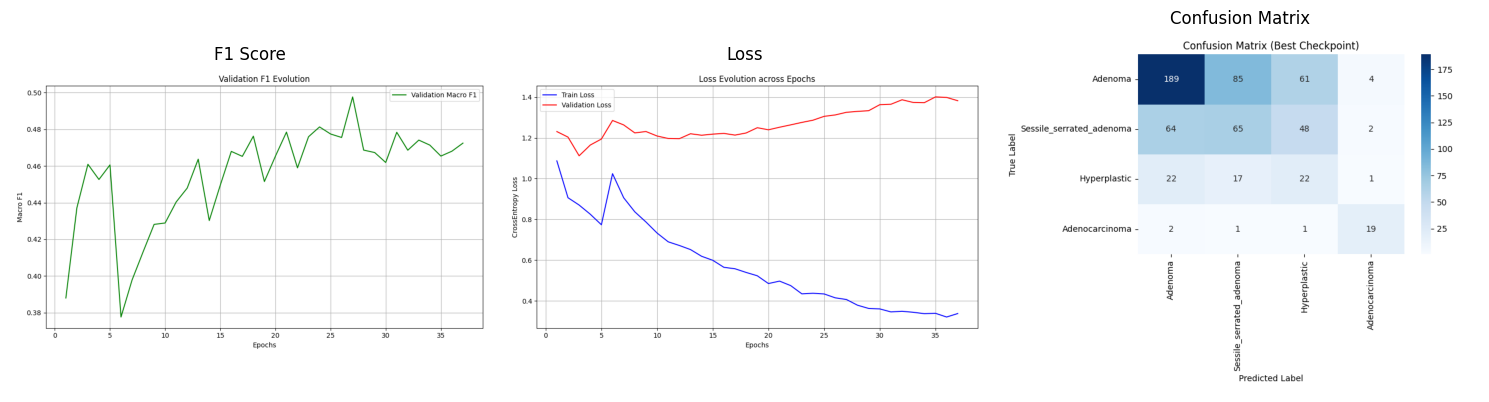

In [4]:
baseline_img_dir = Path('unified_images')
baseline_csv_dir = Path('unified_data_baseline.csv')
results_dir = Path('baseline_experiment1')

trained_model, validation_loader = ModelTrain.train(baseline_csv_dir, baseline_img_dir, results_dir, train1)

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
image_paths = [results_path / F1_FIG_NAME, results_path / LOSS_FIG_NAME, results_path / CONF_MATRIX_NAME]

titles = ["F1 Score", "Loss", "Confusion Matrix"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img_path, title in zip(axes, image_paths, titles):
    # Carga de la imagen
    img = cv2.imread(str(img_path))
    
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(0.5, 0.5, 'Error: Image not found', fontsize=12, color='red',ha='center', va='center', transform=ax.transAxes)
        
    ax.set_title(title, fontsize=12)
    ax.axis('off') 

plt.tight_layout()
plt.show()

In [5]:
train2 = ModelTrain.TrainingConfig(    
    train_ratio=0.8,
    random_state=42,
    input_size=224,
    val_resize_size=256,
    batch_size=32,
    num_workers=0,
    num_epochs=100,

    warmup_epochs=5,
    trainable_backbone_blocks=3,

    head_lr=1e-3,
    fine_tune_head_lr=2e-4,
    backbone_lr=1e-5,

    weight_decay=5e-4,
    dropout=0.3,
    stochastic_depth_prob=0.1,
    label_smoothing=0.02,

    scheduler_factor=0.5,
    scheduler_patience=2,
    early_stopping_patience=10,
    min_lr=1e-6,
    gradient_clip_norm=1.0,

    use_weighted_loss=True,
    use_weighted_sampler=False, # Cambio aquí True -> False
    enable_backbone_finetuning=True,
    full_network_finetuning=False
    )

Hardware assigned for tensor computations: cuda
Train class distribution:
histology
Adenoma                     1555
Sessile_serrated_adenoma     660
Hyperplastic                 337
Adenocarcinoma                97

Validation class distribution:
histology
Adenoma                     339
Sessile_serrated_adenoma    179
Hyperplastic                 62
Adenocarcinoma               23

Loss weights: {'Adenoma': 0.4605, 'Sessile_serrated_adenoma': 0.7068, 'Hyperplastic': 0.9891, 'Adenocarcinoma': 1.8436}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment2


Training Progress:   5%|▌         | 5/100 [04:36<1:27:35, 55.32s/epoch, Stage=head_only, Train Loss=0.8895, Val Loss=1.1115, Val F1=0.4975, LR=1.0e-03]        


Switching to partial backbone fine-tuning (3 blocks) at epoch 6.


Training Progress:  13%|█▎        | 13/100 [13:00<1:27:00, 60.01s/epoch, Stage=last_3_blocks, Train Loss=0.7931, Val Loss=1.1309, Val F1=0.4647, LR=5.0e-06/1.0e-04]
c:\Users\luis\Documents\TFG - Data-Centric AI\src\ModelTrain.py:725: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control


Early stopping triggered after 10 epochs without improving macro-F1.

Optimization sequence completed. Best validation macro-F1: 0.5049 at epoch 4.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment2'.


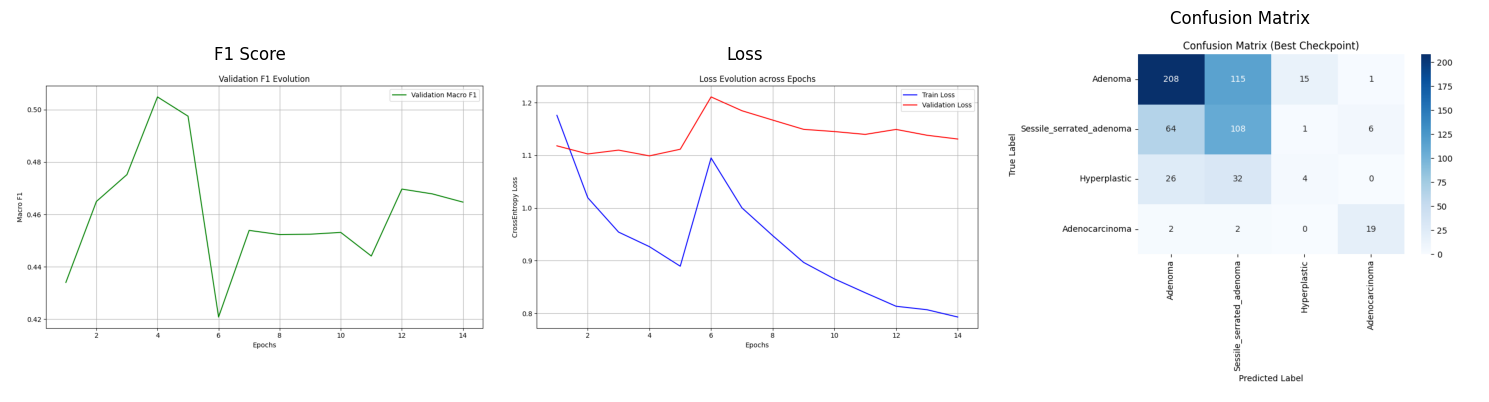

In [6]:
baseline_img_dir = Path('unified_images')
baseline_csv_dir = Path('unified_data_baseline.csv')
results_dir = Path('baseline_experiment2')

trained_model, validation_loader = ModelTrain.train(baseline_csv_dir, baseline_img_dir, results_dir, train2)

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
image_paths = [results_path / F1_FIG_NAME, results_path / LOSS_FIG_NAME, results_path / CONF_MATRIX_NAME]

titles = ["F1 Score", "Loss", "Confusion Matrix"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img_path, title in zip(axes, image_paths, titles):
    # Carga de la imagen
    img = cv2.imread(str(img_path))
    
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(0.5, 0.5, 'Error: Image not found', fontsize=12, color='red',ha='center', va='center', transform=ax.transAxes)
        
    ax.set_title(title, fontsize=12)
    ax.axis('off') 

plt.tight_layout()
plt.show()

In [7]:
train3 = ModelTrain.TrainingConfig(    
    train_ratio=0.8,
    random_state=42,
    input_size=224,
    val_resize_size=256,
    batch_size=32,
    num_workers=0,
    num_epochs=100,

    warmup_epochs=5,
    trainable_backbone_blocks=3,

    head_lr=1e-3,
    fine_tune_head_lr=2e-4,
    backbone_lr=1e-5,

    weight_decay=5e-4,
    dropout=0.3,
    stochastic_depth_prob=0.1,
    label_smoothing=0.02,

    scheduler_factor=0.5,
    scheduler_patience=2,
    early_stopping_patience=10,
    min_lr=1e-6,
    gradient_clip_norm=1.0,

    use_weighted_loss=True,
    use_weighted_sampler=False, 
    enable_backbone_finetuning=True,
    full_network_finetuning=True # Cambio aquí False -> True
    )

Hardware assigned for tensor computations: cuda
Train class distribution:
histology
Adenoma                     1555
Sessile_serrated_adenoma     660
Hyperplastic                 337
Adenocarcinoma                97

Validation class distribution:
histology
Adenoma                     339
Sessile_serrated_adenoma    179
Hyperplastic                 62
Adenocarcinoma               23

Loss weights: {'Adenoma': 0.4605, 'Sessile_serrated_adenoma': 0.7068, 'Hyperplastic': 0.9891, 'Adenocarcinoma': 1.8436}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment3_recheck


Training Progress:   5%|▌         | 5/100 [04:37<1:27:42, 55.40s/epoch, Stage=head_only, Train Loss=0.8895, Val Loss=1.1115, Val F1=0.4975, LR=1.0e-03]        


Switching to full-network fine-tuning at epoch 6.


Training Progress:  13%|█▎        | 13/100 [13:50<1:32:36, 63.87s/epoch, Stage=full_network, Train Loss=0.7829, Val Loss=1.1175, Val F1=0.5032, LR=5.0e-06/1.0e-04]
c:\Users\luis\Documents\TFG - Data-Centric AI\src\ModelTrain.py:725: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control 


Early stopping triggered after 10 epochs without improving macro-F1.

Optimization sequence completed. Best validation macro-F1: 0.5049 at epoch 4.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment3_recheck'.


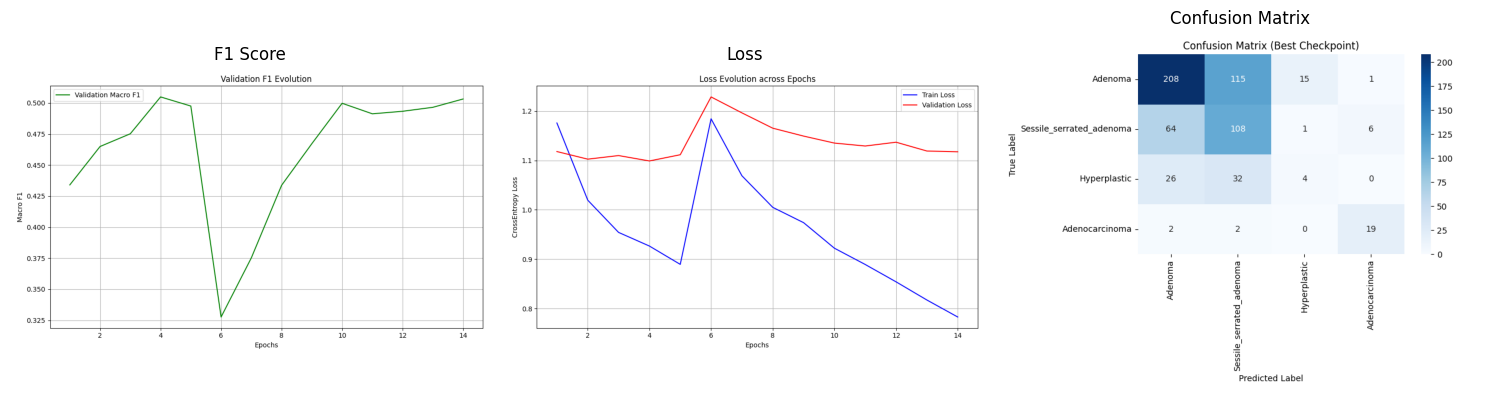

In [8]:
baseline_img_dir = Path('unified_images')
baseline_csv_dir = Path('unified_data_baseline.csv')
results_dir = Path('baseline_experiment3_recheck')

trained_model, validation_loader = ModelTrain.train(baseline_csv_dir, baseline_img_dir, results_dir, train3)

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
image_paths = [results_path / F1_FIG_NAME, results_path / LOSS_FIG_NAME, results_path / CONF_MATRIX_NAME]

titles = ["F1 Score", "Loss", "Confusion Matrix"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img_path, title in zip(axes, image_paths, titles):
    # Carga de la imagen
    img = cv2.imread(str(img_path))
    
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(0.5, 0.5, 'Error: Image not found', fontsize=12, color='red',ha='center', va='center', transform=ax.transAxes)
        
    ax.set_title(title, fontsize=12)
    ax.axis('off') 

plt.tight_layout()
plt.show()

In [9]:
train4 = ModelTrain.TrainingConfig(    
    train_ratio=0.8,
    random_state=42,
    input_size=224,
    val_resize_size=256,
    batch_size=32,
    num_workers=0,
    num_epochs=100,

    warmup_epochs=5,
    trainable_backbone_blocks=3,

    head_lr=1e-3,
    fine_tune_head_lr=1e-4, # Cambio aquí 2e-4 -> 1e-5
    backbone_lr=5e-6, # Cambio aquí 1e-5 -> 5e-6

    weight_decay=5e-4,
    dropout=0.4, # Cambio aquí 0.3 -> 0.4
    stochastic_depth_prob=0.15, # Cambio aquí 0.1 -> 0.15
    label_smoothing=0.02,

    scheduler_factor=0.5,
    scheduler_patience=2,
    early_stopping_patience=10,
    min_lr=1e-6,
    gradient_clip_norm=1.0,

    use_weighted_loss=True,
    use_weighted_sampler=False, 
    enable_backbone_finetuning=True,
    full_network_finetuning=True 
    )

Hardware assigned for tensor computations: cuda
Train class distribution:
histology
Adenoma                     1555
Sessile_serrated_adenoma     660
Hyperplastic                 337
Adenocarcinoma                97

Validation class distribution:
histology
Adenoma                     339
Sessile_serrated_adenoma    179
Hyperplastic                 62
Adenocarcinoma               23

Loss weights: {'Adenoma': 0.4605, 'Sessile_serrated_adenoma': 0.7068, 'Hyperplastic': 0.9891, 'Adenocarcinoma': 1.8436}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment4


Training Progress:   5%|▌         | 5/100 [04:36<1:27:30, 55.27s/epoch, Stage=head_only, Train Loss=0.9136, Val Loss=1.1183, Val F1=0.4955, LR=1.0e-03]        


Switching to full-network fine-tuning at epoch 6.


Training Progress:  13%|█▎        | 13/100 [13:48<1:32:24, 63.72s/epoch, Stage=full_network, Train Loss=0.9409, Val Loss=1.1431, Val F1=0.4732, LR=5.0e-06/1.0e-04]
c:\Users\luis\Documents\TFG - Data-Centric AI\src\ModelTrain.py:725: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control 


Early stopping triggered after 10 epochs without improving macro-F1.

Optimization sequence completed. Best validation macro-F1: 0.5013 at epoch 4.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment4'.


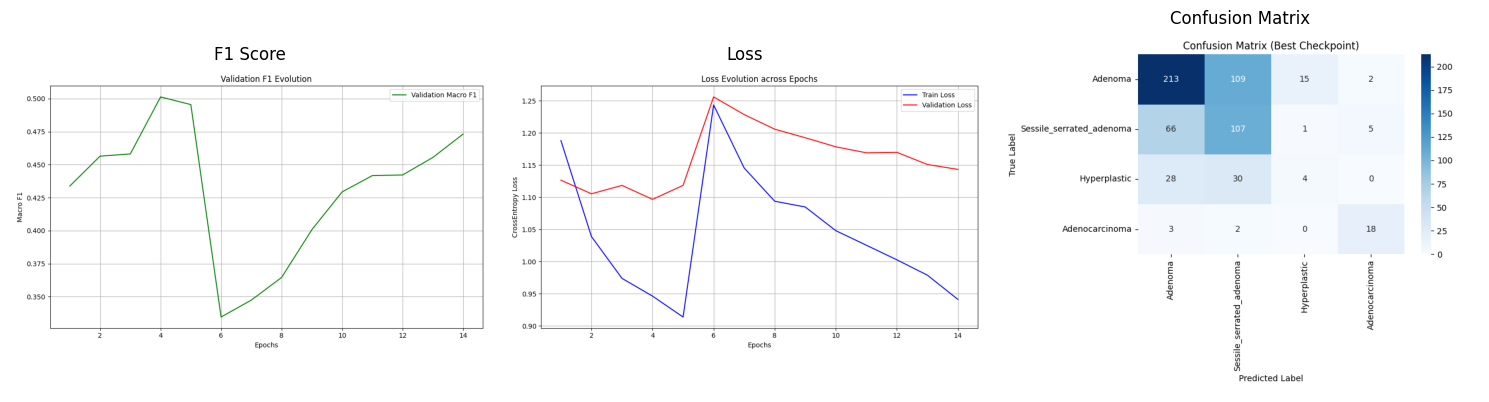

In [10]:
baseline_img_dir = Path('unified_images')
baseline_csv_dir = Path('unified_data_baseline.csv')
results_dir = Path('baseline_experiment4')

trained_model, validation_loader = ModelTrain.train(baseline_csv_dir, baseline_img_dir, results_dir, train4)

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
image_paths = [results_path / F1_FIG_NAME, results_path / LOSS_FIG_NAME, results_path / CONF_MATRIX_NAME]

titles = ["F1 Score", "Loss", "Confusion Matrix"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img_path, title in zip(axes, image_paths, titles):
    # Carga de la imagen
    img = cv2.imread(str(img_path))
    
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(0.5, 0.5, 'Error: Image not found', fontsize=12, color='red',ha='center', va='center', transform=ax.transAxes)
        
    ax.set_title(title, fontsize=12)
    ax.axis('off') 

plt.tight_layout()
plt.show()

In [11]:
train5 = ModelTrain.TrainingConfig(
    train_ratio=0.8,
    random_state=42,
    input_size=224,
    val_resize_size=256,
    batch_size=32,
    num_workers=0,
    num_epochs=100,

    warmup_epochs=5,
    trainable_backbone_blocks=3,

    head_lr=1e-3,
    fine_tune_head_lr=1.5e-4,
    backbone_lr=7e-6,

    weight_decay=5e-4,
    dropout=0.35,
    stochastic_depth_prob=0.12,
    label_smoothing=0.02,

    scheduler_factor=0.5,
    scheduler_patience=2,
    early_stopping_patience=10,
    min_lr=1e-6,
    gradient_clip_norm=1.0,

    use_weighted_loss=True,
    use_weighted_sampler=False,
    enable_backbone_finetuning=True,
    full_network_finetuning=True
)

Hardware assigned for tensor computations: cuda
Train class distribution:
histology
Adenoma                     1555
Sessile_serrated_adenoma     660
Hyperplastic                 337
Adenocarcinoma                97

Validation class distribution:
histology
Adenoma                     339
Sessile_serrated_adenoma    179
Hyperplastic                 62
Adenocarcinoma               23

Loss weights: {'Adenoma': 0.4605, 'Sessile_serrated_adenoma': 0.7068, 'Hyperplastic': 0.9891, 'Adenocarcinoma': 1.8436}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment5


Training Progress:   5%|▌         | 5/100 [04:38<1:28:21, 55.81s/epoch, Stage=head_only, Train Loss=0.8995, Val Loss=1.1154, Val F1=0.4865, LR=1.0e-03]        


Switching to full-network fine-tuning at epoch 6.


Training Progress:  13%|█▎        | 13/100 [13:52<1:32:48, 64.01s/epoch, Stage=full_network, Train Loss=0.8681, Val Loss=1.1215, Val F1=0.4974, LR=7.0e-06/1.5e-04]
c:\Users\luis\Documents\TFG - Data-Centric AI\src\ModelTrain.py:725: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control 


Early stopping triggered after 10 epochs without improving macro-F1.

Optimization sequence completed. Best validation macro-F1: 0.5001 at epoch 4.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment5'.


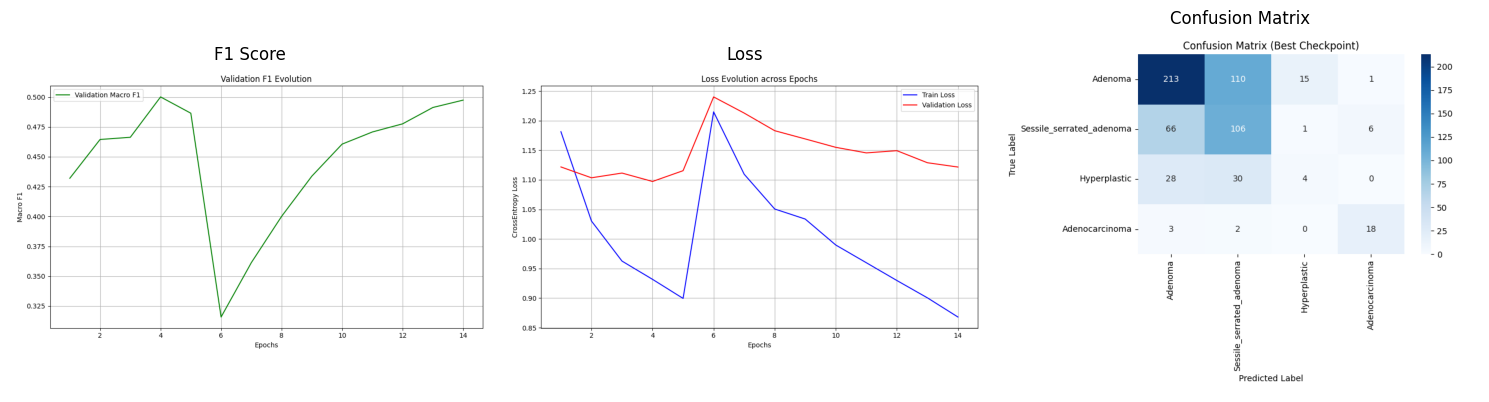

In [12]:
baseline_img_dir = Path('unified_images')
baseline_csv_dir = Path('unified_data_baseline.csv')
results_dir = Path('baseline_experiment5')

trained_model, validation_loader = ModelTrain.train(baseline_csv_dir, baseline_img_dir, results_dir, train5)

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
image_paths = [results_path / F1_FIG_NAME, results_path / LOSS_FIG_NAME, results_path / CONF_MATRIX_NAME]

titles = ["F1 Score", "Loss", "Confusion Matrix"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img_path, title in zip(axes, image_paths, titles):
    # Carga de la imagen
    img = cv2.imread(str(img_path))
    
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(0.5, 0.5, 'Error: Image not found', fontsize=12, color='red',ha='center', va='center', transform=ax.transAxes)
        
    ax.set_title(title, fontsize=12)
    ax.axis('off') 

plt.tight_layout()
plt.show()

In [13]:
train6 = ModelTrain.TrainingConfig(    
    train_ratio=0.8,
    random_state=42,
    input_size=224,
    val_resize_size=256,
    batch_size=32,
    num_workers=0,
    num_epochs=100,

    warmup_epochs=10,
    trainable_backbone_blocks=3,

    head_lr=1e-3,
    fine_tune_head_lr=2e-4,
    backbone_lr=1e-5,

    weight_decay=5e-4,
    dropout=0.3,
    stochastic_depth_prob=0.1,
    label_smoothing=0.02,

    scheduler_factor=0.5,
    scheduler_patience=2,
    early_stopping_patience=10,
    min_lr=1e-6,
    gradient_clip_norm=1.0,

    use_weighted_loss=True,
    use_weighted_sampler=False, 
    enable_backbone_finetuning=True,
    full_network_finetuning=True # Cambio aquí False -> True
    )

Hardware assigned for tensor computations: cuda
Train class distribution:
histology
Adenoma                     1555
Sessile_serrated_adenoma     660
Hyperplastic                 337
Adenocarcinoma                97

Validation class distribution:
histology
Adenoma                     339
Sessile_serrated_adenoma    179
Hyperplastic                 62
Adenocarcinoma               23

Loss weights: {'Adenoma': 0.4605, 'Sessile_serrated_adenoma': 0.7068, 'Hyperplastic': 0.9891, 'Adenocarcinoma': 1.8436}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment6


Training Progress:  10%|█         | 10/100 [09:12<1:22:41, 55.13s/epoch, Stage=head_only, Train Loss=0.8258, Val Loss=1.1287, Val F1=0.5227, LR=1.0e-03]       


Switching to full-network fine-tuning at epoch 11.


Training Progress:  18%|█▊        | 18/100 [18:26<1:24:01, 61.48s/epoch, Stage=full_network, Train Loss=0.7954, Val Loss=1.1597, Val F1=0.5030, LR=1.0e-05/2.0e-04]
c:\Users\luis\Documents\TFG - Data-Centric AI\src\ModelTrain.py:725: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control 


Early stopping triggered after 10 epochs without improving macro-F1.

Optimization sequence completed. Best validation macro-F1: 0.5337 at epoch 9.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment6'.


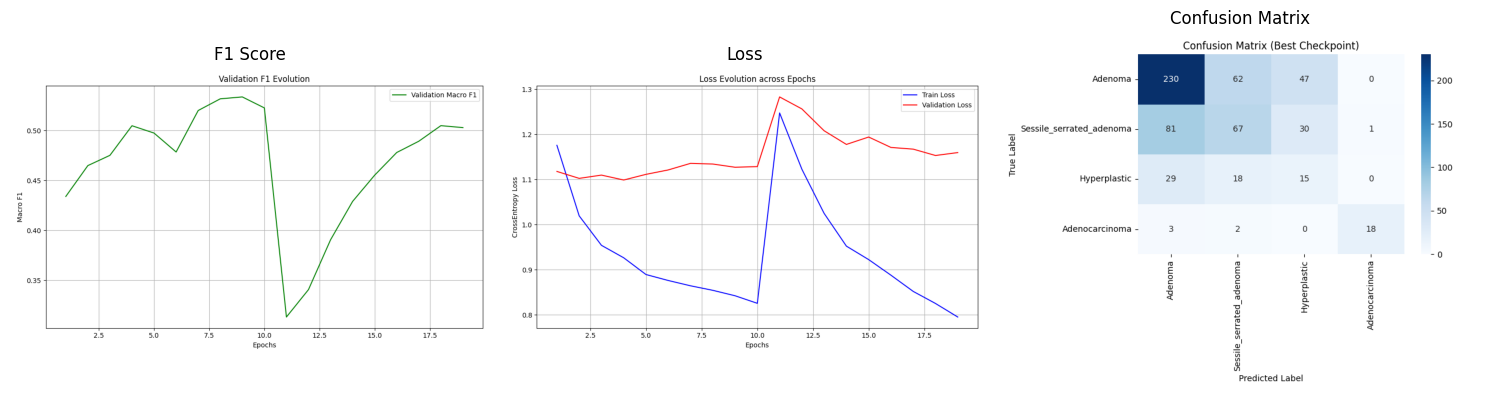

In [14]:
baseline_img_dir = Path('unified_images')
baseline_csv_dir = Path('unified_data_baseline.csv')
results_dir = Path('baseline_experiment6')

trained_model, validation_loader = ModelTrain.train(baseline_csv_dir, baseline_img_dir, results_dir, train6)

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
image_paths = [results_path / F1_FIG_NAME, results_path / LOSS_FIG_NAME, results_path / CONF_MATRIX_NAME]

titles = ["F1 Score", "Loss", "Confusion Matrix"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img_path, title in zip(axes, image_paths, titles):
    # Carga de la imagen
    img = cv2.imread(str(img_path))
    
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(0.5, 0.5, 'Error: Image not found', fontsize=12, color='red',ha='center', va='center', transform=ax.transAxes)
        
    ax.set_title(title, fontsize=12)
    ax.axis('off') 

plt.tight_layout()
plt.show()

In [15]:
train7 = ModelTrain.TrainingConfig(    
    train_ratio=0.8,
    random_state=42,
    input_size=224,
    val_resize_size=256,
    batch_size=32,
    num_workers=0,
    num_epochs=100,

    warmup_epochs=8,
    trainable_backbone_blocks=3,

    head_lr=1e-3,
    fine_tune_head_lr=2e-4,
    backbone_lr=1e-5,

    weight_decay=5e-4,
    dropout=0.3,
    stochastic_depth_prob=0.1,
    label_smoothing=0.02,

    scheduler_factor=0.5,
    scheduler_patience=2,
    early_stopping_patience=10,
    min_lr=1e-6,
    gradient_clip_norm=1.0,

    use_weighted_loss=True,
    use_weighted_sampler=False, 
    enable_backbone_finetuning=True,
    full_network_finetuning=True # Cambio aquí False -> True
    )

Hardware assigned for tensor computations: cuda
Train class distribution:
histology
Adenoma                     1555
Sessile_serrated_adenoma     660
Hyperplastic                 337
Adenocarcinoma                97

Validation class distribution:
histology
Adenoma                     339
Sessile_serrated_adenoma    179
Hyperplastic                 62
Adenocarcinoma               23

Loss weights: {'Adenoma': 0.4605, 'Sessile_serrated_adenoma': 0.7068, 'Hyperplastic': 0.9891, 'Adenocarcinoma': 1.8436}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment7


Training Progress:   8%|▊         | 8/100 [07:24<1:25:29, 55.75s/epoch, Stage=head_only, Train Loss=0.8546, Val Loss=1.1343, Val F1=0.5318 [saved], LR=1.0e-03]


Switching to full-network fine-tuning at epoch 9.


Training Progress:  17%|█▋        | 17/100 [17:40<1:26:20, 62.41s/epoch, Stage=full_network, Train Loss=0.7706, Val Loss=1.1385, Val F1=0.5211, LR=1.0e-05/2.0e-04]
c:\Users\luis\Documents\TFG - Data-Centric AI\src\ModelTrain.py:725: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control 


Early stopping triggered after 10 epochs without improving macro-F1.

Optimization sequence completed. Best validation macro-F1: 0.5318 at epoch 8.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment7'.


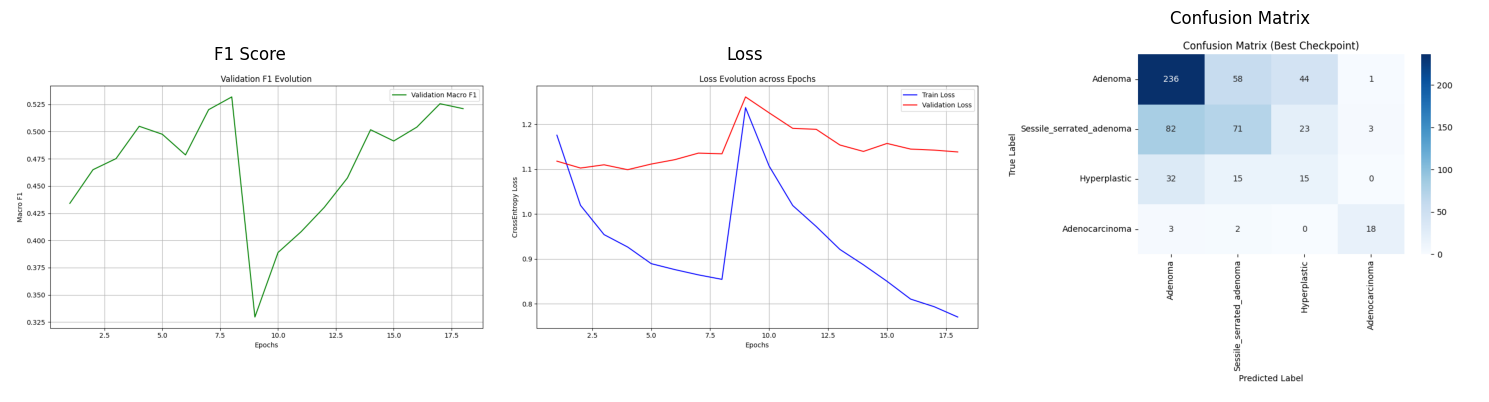

In [16]:
baseline_img_dir = Path('unified_images')
baseline_csv_dir = Path('unified_data_baseline.csv')
results_dir = Path('baseline_experiment7')

trained_model, validation_loader = ModelTrain.train(baseline_csv_dir, baseline_img_dir, results_dir, train7)

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
image_paths = [results_path / F1_FIG_NAME, results_path / LOSS_FIG_NAME, results_path / CONF_MATRIX_NAME]

titles = ["F1 Score", "Loss", "Confusion Matrix"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img_path, title in zip(axes, image_paths, titles):
    # Carga de la imagen
    img = cv2.imread(str(img_path))
    
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(0.5, 0.5, 'Error: Image not found', fontsize=12, color='red',ha='center', va='center', transform=ax.transAxes)
        
    ax.set_title(title, fontsize=12)
    ax.axis('off') 

plt.tight_layout()
plt.show()

In [ ]:
train8 = ModelTrain.TrainingConfig(    
    train_ratio=0.8,
    random_state=42,
    input_size=224,
    val_resize_size=256,
    batch_size=32,
    num_workers=0,
    num_epochs=100,

    warmup_epochs=0,
    trainable_backbone_blocks=3,

    head_lr=1e-3,
    fine_tune_head_lr=1e-4,
    backbone_lr=1e-5,

    weight_decay=5e-4,
    dropout=0.3,
    stochastic_depth_prob=0.1,
    label_smoothing=0.02,

    scheduler_factor=0.5,
    scheduler_patience=2,
    early_stopping_patience=10,
    min_lr=1e-6,
    gradient_clip_norm=1.0,

    use_weighted_loss=True,
    use_weighted_sampler=False, 
    enable_backbone_finetuning=True,
    full_network_finetuning=True
    )

Hardware assigned for tensor computations: cuda
Train class distribution:
histology
Adenoma                     1555
Sessile_serrated_adenoma     660
Hyperplastic                 337
Adenocarcinoma                97

Validation class distribution:
histology
Adenoma                     339
Sessile_serrated_adenoma    179
Hyperplastic                 62
Adenocarcinoma               23

Loss weights: {'Adenoma': 0.4605, 'Sessile_serrated_adenoma': 0.7068, 'Hyperplastic': 0.9891, 'Adenocarcinoma': 1.8436}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment8


Training Progress:   0%|          | 0/100 [00:00<?, ?epoch/s]


Switching to full-network fine-tuning at epoch 1.


Training Progress:  39%|███▉      | 39/100 [41:03<1:04:13, 63.17s/epoch, Stage=full_network, Train Loss=0.5112, Val Loss=1.1614, Val F1=0.5168, LR=1.0e-06/1.6e-06]        
c:\Users\luis\Documents\TFG - Data-Centric AI\src\ModelTrain.py:725: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full 


Early stopping triggered after 10 epochs without improving macro-F1.

Optimization sequence completed. Best validation macro-F1: 0.5412 at epoch 30.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment8'.


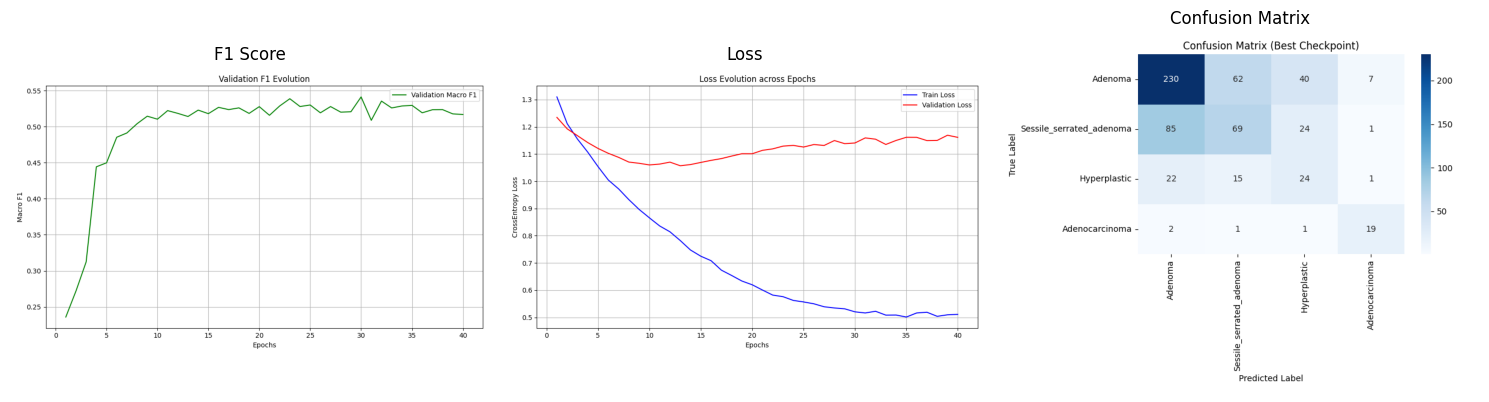

In [18]:
baseline_img_dir = Path('unified_images')
baseline_csv_dir = Path('unified_data_baseline.csv')
results_dir = Path('baseline_experiment8')

trained_model, validation_loader = ModelTrain.train(baseline_csv_dir, baseline_img_dir, results_dir, train8)

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
image_paths = [results_path / F1_FIG_NAME, results_path / LOSS_FIG_NAME, results_path / CONF_MATRIX_NAME]

titles = ["F1 Score", "Loss", "Confusion Matrix"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img_path, title in zip(axes, image_paths, titles):
    # Carga de la imagen
    img = cv2.imread(str(img_path))
    
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(0.5, 0.5, 'Error: Image not found', fontsize=12, color='red',ha='center', va='center', transform=ax.transAxes)
        
    ax.set_title(title, fontsize=12)
    ax.axis('off') 

plt.tight_layout()
plt.show()